# **Capstone project: Providing data-driven suggestions for HR**

## Description and deliverables

This capstone project is an opportunity for you to analyze a dataset and build predictive models that can provide insights to the Human Resources (HR) department of a large consulting firm.

Upon completion, you will have two artifacts that you will be able to present to future employers. One is a brief one-page summary of this project that you will present to external stakeholders as the data professional in Salifort Motors. The other is a complete code notebook provided here. Based on your prior coursework, select one method to complete this project: use either a regression model or a machine learning model to predict whether an employee will leave the company. The exemplar following this actiivty shows both approaches, but you only need to do one.

In your deliverables, you will include the model evaluation (and interpretation if applicable), a data visualization(s) of your choice that is directly related to the question you ask, ethical considerations, and the resources you used to troubleshoot and find answers or solutions.


# **PACE stages**


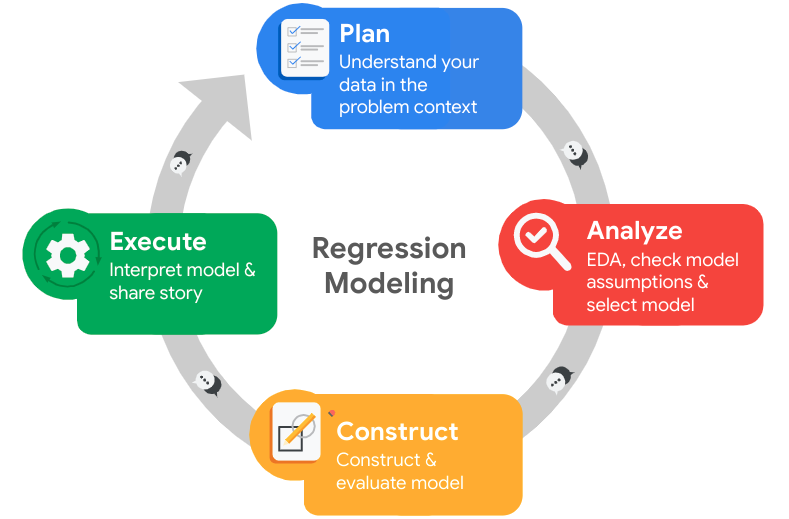

## **Pace: Plan**

Consider the questions in your PACE Strategy Document to reflect on the Plan stage.

In this stage, consider the following:

### Understand the business scenario and problem

The HR department at Salifort Motors wants to take some initiatives to improve employee satisfaction levels at the company. They collected data from employees, but now they don’t know what to do with it. They refer to you as a data analytics professional and ask you to provide data-driven suggestions based on your understanding of the data. They have the following question: what’s likely to make the employee leave the company?

Your goals in this project are to analyze the data collected by the HR department and to build a model that predicts whether or not an employee will leave the company.

If you can predict employees likely to quit, it might be possible to identify factors that contribute to their leaving. Because it is time-consuming and expensive to find, interview, and hire new employees, increasing employee retention will be beneficial to the company.

### Familiarize yourself with the HR dataset

The dataset that you'll be using in this lab contains 15,000 rows and 10 columns for the variables listed below. 

**Note:** you don't need to download any data to complete this lab. For more information about the data, refer to its source on [Kaggle](https://www.kaggle.com/datasets/mfaisalqureshi/hr-analytics-and-job-prediction?select=HR_comma_sep.csv).

Variable  |Description |
-----|-----|
satisfaction_level|Employee-reported job satisfaction level [0&ndash;1]|
last_evaluation|Score of employee's last performance review [0&ndash;1]|
number_project|Number of projects employee contributes to|
average_monthly_hours|Average number of hours employee worked per month|
time_spend_company|How long the employee has been with the company (years)
Work_accident|Whether or not the employee experienced an accident while at work
left|Whether or not the employee left the company
promotion_last_5years|Whether or not the employee was promoted in the last 5 years
Department|The employee's department
salary|The employee's salary (U.S. dollars)

💭
### Reflect on these questions as you complete the plan stage.

*  Who are your stakeholders for this project?
- What are you trying to solve or accomplish?
- What are your initial observations when you explore the data?
- What resources do you find yourself using as you complete this stage? (Make sure to include the links.)
- Do you have any ethical considerations in this stage?




[Double-click to enter your responses here.]

## Step 1. Imports

*   Import packages
*   Load dataset



### Import packages

In [2]:
# Import packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score

### Load dataset

`Pandas` is used to read a dataset called **`HR_capstone_dataset.csv`.**  As shown in this cell, the dataset has been automatically loaded in for you. You do not need to download the .csv file, or provide more code, in order to access the dataset and proceed with this lab. Please continue with this activity by completing the following instructions.

In [3]:
# RUN THIS CELL TO IMPORT YOUR DATA. 

# Load dataset into a dataframe
### YOUR CODE HERE ###
df0 = pd.read_csv("HR_capstone_dataset.csv")


# Display first few rows of the dataframe
df0.head()


,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


## Step 2. Data Exploration (Initial EDA and data cleaning)

- Understand your variables
- Clean your dataset (missing data, redundant data, outliers)



### Gather basic information about the data

In [4]:
# Gather basic information about the data
df0.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     14999 non-null  float64
 1   last_evaluation        14999 non-null  float64
 2   number_project         14999 non-null  int64  
 3   average_montly_hours   14999 non-null  int64  
 4   time_spend_company     14999 non-null  int64  
 5   Work_accident          14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotion_last_5years  14999 non-null  int64  
 8   Department             14999 non-null  object 
 9   salary                 14999 non-null  object 
dtypes: float64(2), int64(6), object(2)
memory usage: 1.1+ MB


### Gather descriptive statistics about the data

In [5]:
# Gather descriptive statistics about the data
df0.describe()


,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years
count,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000
mean,0.612834,0.716102,3.803054,201.050337,3.498233,0.144610,0.238083,0.021268
std,0.248631,0.171169,1.232592,49.943099,1.460136,0.351719,0.425924,0.144281
min,0.090000,0.360000,2.000000,96.000000,2.000000,0.000000,0.000000,0.000000
25%,0.440000,0.560000,3.000000,156.000000,3.000000,0.000000,0.000000,0.000000
50%,0.640000,0.720000,4.000000,200.000000,3.000000,0.000000,0.000000,0.000000
75%,0.820000,0.870000,5.000000,245.000000,4.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,7.000000,310.000000,10.000000,1.000000,1.000000,1.000000


### Rename columns

As a data cleaning step, rename the columns as needed. Standardize the column names so that they are all in `snake_case`, correct any column names that are misspelled, and make column names more concise as needed.

In [6]:
# Display all column names
df0.columns


Index(['satisfaction_level', 'last_evaluation', 'number_project',
       'average_montly_hours', 'time_spend_company', 'Work_accident', 'left',
       'promotion_last_5years', 'Department', 'salary'],
      dtype='object')

In [7]:
# Rename columns as needed
df0 = df0.rename(columns={'Work_accident': 'work_accident',
                          'average_montly_hours': 'average_monthly_hours',
                          'time_spend_company': 'time_spend_company',
                          'Promotion_last_5years': 'promotion_last_5years',
                          'Department': 'department'})


# Display all column names after the update
df0.columns


Index(['satisfaction_level', 'last_evaluation', 'number_project',
       'average_monthly_hours', 'time_spend_company', 'work_accident', 'left',
       'promotion_last_5years', 'department', 'salary'],
      dtype='object')

### Check missing values

Check for any missing values in the data.

In [8]:
# Check for missing values
df0.isna().sum()


satisfaction_level       0
last_evaluation          0
number_project           0
average_monthly_hours    0
time_spend_company       0
work_accident            0
left                     0
promotion_last_5years    0
department               0
salary                   0
dtype: int64

### Check duplicates

Check for any duplicate entries in the data.

In [9]:
# Check for duplicates
df0.duplicated().sum()


3008

In [10]:
# Inspect some rows containing duplicates as needed
df0[df0.duplicated()].head()


,satisfaction_level,last_evaluation,number_project,average_monthly_hours,time_spend_company,work_accident,left,promotion_last_5years,department,salary
396,0.46,0.57,2,139,3,0,1,0,sales,low
866,0.41,0.46,2,128,3,0,1,0,accounting,low
1317,0.37,0.51,2,127,3,0,1,0,sales,medium
1368,0.41,0.52,2,132,3,0,1,0,RandD,low
1461,0.42,0.53,2,142,3,0,1,0,sales,low


In [11]:
# Drop duplicates and save resulting dataframe in a new variable as needed
df = df0.drop_duplicates(keep='first').reset_index(drop=True)


# Display first few rows of new dataframe as needed
df.head()


,satisfaction_level,last_evaluation,number_project,average_monthly_hours,time_spend_company,work_accident,left,promotion_last_5years,department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


### Check outliers

Check for outliers in the data.

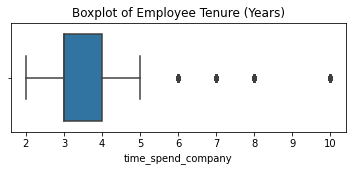

In [12]:
# Create a boxplot to visualize distribution of `time_spend_company` and detect any outliers
plt.figure(figsize=(6, 2))
sns.boxplot(x=df['time_spend_company'])
plt.title('Boxplot of Employee Tenure (Years)')
plt.show()



In [13]:
# Determine the number of rows containing outliers
percentile25 = df['time_spend_company'].quantile(0.25)
percentile75 = df['time_spend_company'].quantile(0.75)
iqr = percentile75 - percentile25
upper_limit = percentile75 + 1.5 * iqr
lower_limit = percentile25 - 1.5 * iqr
outliers = df[(df['time_spend_company'] > upper_limit) | (df['time_spend_company'] < lower_limit)]
print("Number of rows containing outliers in time_spend_company:", len(outliers))


Number of rows containing outliers in time_spend_company: 824


Certain types of models are more sensitive to outliers than others. When you get to the stage of building your model, consider whether to remove outliers, based on the type of model you decide to use.

# pAce: Analyze Stage
- Perform EDA (analyze relationships between variables)



💭
### Reflect on these questions as you complete the analyze stage.

- What did you observe about the relationships between variables?
- What do you observe about the distributions in the data?
- What transformations did you make with your data? Why did you chose to make those decisions?
- What are some purposes of EDA before constructing a predictive model?
- What resources do you find yourself using as you complete this stage? (Make sure to include the links.)
- Do you have any ethical considerations in this stage?




Key Observations: Employee turnover is heavily correlated with high workload metrics, specifically average monthly hours and project counts, which point toward burnout.
Distributions: The dataset has imbalanced classes since a higher percentage of employees stayed compared to those who left. Workload metrics show a bimodal split among departures.
Data Transformations: I cleaned the data by dropping duplicate rows to avoid synthetic model overfitting and standardized column names to snake_case for operational consistency.
Purpose of EDA: EDA allows us to understand feature shapes, detect structural anomalies or outliers, and identify linear or non-linear behaviors before feed data to complex classifiers.
Resources Used: Official documentation for Pandas (https://pandas.pydata.org) and Seaborn (https://seaborn.pydata.org).
Ethical Considerations: Data variables must remain anonymous. Insights will be used strictly at a systemic level to adjust corporate workloads rather than penalizing individuals.

## Step 2. Data Exploration (Continue EDA)

Begin by understanding how many employees left and what percentage of all employees this figure represents.

In [14]:
# Get numbers of people who left vs. stayed
print("Counts of left vs. stayed:")
print(df['left'].value_counts())
print()

# Get percentages of people who left vs. stayed
print("Percentages of left vs. stayed:")
print(df['left'].value_counts(normalize=True) * 100)


Counts of left vs. stayed:
0    10000
1     1991
Name: left, dtype: int64

Percentages of left vs. stayed:
0    83.39588
1    16.60412
Name: left, dtype: float64


### Data visualizations

Now, examine variables that you're interested in, and create plots to visualize relationships between variables in the data.

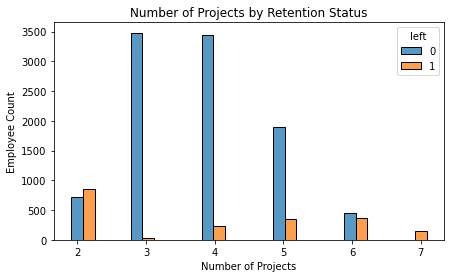

In [15]:
# Create a plot as needed
plt.figure(figsize=(7, 4))
sns.histplot(data=df, x='number_project', hue='left', multiple='dodge', shrink=2)
plt.title('Number of Projects by Retention Status')
plt.xlabel('Number of Projects')
plt.ylabel('Employee Count')
plt.show()


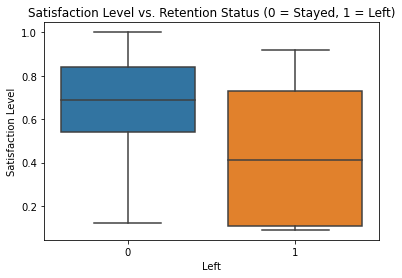

In [16]:
# Create a plot as needed
plt.figure(figsize=(6, 4))
sns.boxplot(data=df, x='left', y='satisfaction_level')
plt.title('Satisfaction Level vs. Retention Status (0 = Stayed, 1 = Left)')
plt.xlabel('Left')
plt.ylabel('Satisfaction Level')
plt.show()


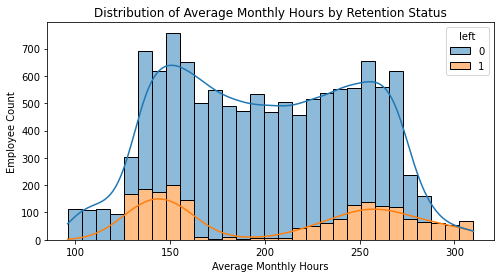

In [17]:
# Create a plot as needed
plt.figure(figsize=(8, 4))
sns.histplot(data=df, x='average_monthly_hours', hue='left', multiple='stack', kde=True)
plt.title('Distribution of Average Monthly Hours by Retention Status')
plt.xlabel('Average Monthly Hours')
plt.ylabel('Employee Count')
plt.show()


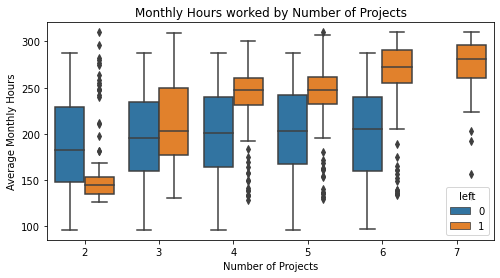

In [18]:
# Create a plot as needed
plt.figure(figsize=(8, 4))
sns.boxplot(data=df, x='number_project', y='average_monthly_hours', hue='left')
plt.title('Monthly Hours worked by Number of Projects')
plt.xlabel('Number of Projects')
plt.ylabel('Average Monthly Hours')
plt.show()


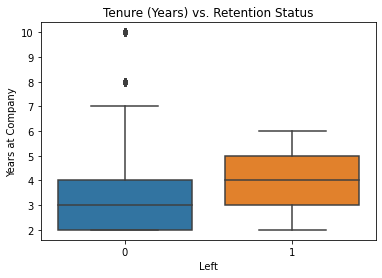

In [19]:
# Create a plot as needed
plt.figure(figsize=(6, 4))
sns.boxplot(data=df, x='left', y='time_spend_company')
plt.title('Tenure (Years) vs. Retention Status')
plt.xlabel('Left')
plt.ylabel('Years at Company')
plt.show()


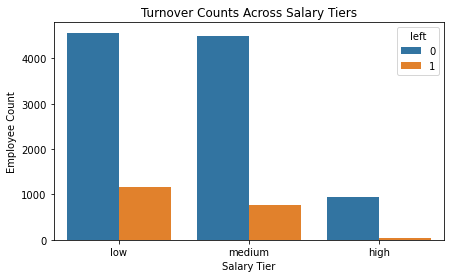

In [21]:
# Create a plot as needed
plt.figure(figsize=(7, 4))
sns.countplot(data=df, x='salary', hue='left', order=['low', 'medium', 'high'])
plt.title('Turnover Counts Across Salary Tiers')
plt.xlabel('Salary Tier')
plt.ylabel('Employee Count')
plt.show()


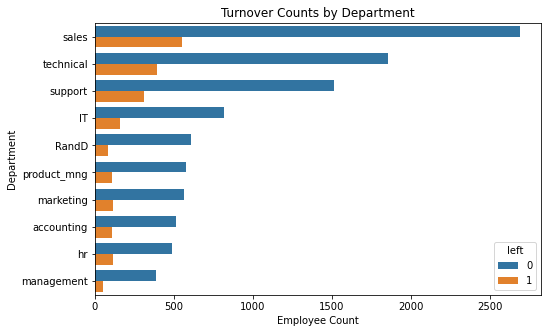

In [22]:
# Create a plot as needed
plt.figure(figsize=(8, 5))
sns.countplot(data=df, y='department', hue='left', order=df['department'].value_counts().index)
plt.title('Turnover Counts by Department')
plt.xlabel('Employee Count')
plt.ylabel('Department')
plt.show()


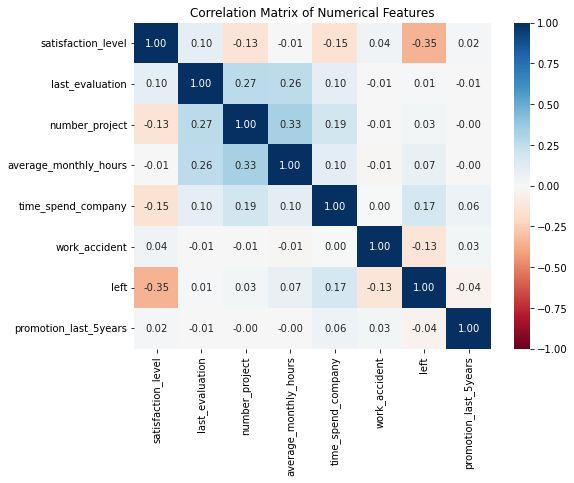

In [23]:
# Create a plot as needed
plt.figure(figsize=(8, 6))
numeric_df = df.drop(columns=['department', 'salary'])
sns.heatmap(numeric_df.corr(), annot=True, cmap='RdBu', fmt='.2f', vmin=-1, vmax=1)
plt.title('Correlation Matrix of Numerical Features')
plt.show()


### Insights

Workload Burnout: Employees who work extreme hours (>240 monthly hours) and handle 6-7 projects have a massive turnover spike. They hit a severe workload ceiling.
Underutilization: Another distinct cluster of departures includes employees with low project counts (2 projects) and very low satisfaction levels, indicating stagnation.
Tenure Milestones: Turnover peaks heavily between 3 to 5 years of tenure. Employees leaving this milestone often maintain strong performance reviews but fail to secure promotions.
Salary Inequity: Low and medium salary tiers bear the brunt of turnover counts compared to the high-salary tier.

# paCe: Construct Stage
- Determine which models are most appropriate
- Construct the model
- Confirm model assumptions
- Evaluate model results to determine how well your model fits the data


🔎
## Recall model assumptions

**Logistic Regression model assumptions**
- Outcome variable is categorical
- Observations are independent of each other
- No severe multicollinearity among X variables
- No extreme outliers
- Linear relationship between each X variable and the logit of the outcome variable
- Sufficiently large sample size





💭
### Reflect on these questions as you complete the constructing stage.

- Do you notice anything odd?
- Which independent variables did you choose for the model and why?
- Are each of the assumptions met?
- How well does your model fit the data?
- Can you improve it? Is there anything you would change about the model?
- What resources do you find yourself using as you complete this stage? (Make sure to include the links.)
- Do you have any ethical considerations in this stage?



Observations: The baseline Logistic Regression model struggling with non-linear distributions, failing to capture the bimodal behavior of workload variables effectively.
Independent Variables Selected: I selected all operational columns (`satisfaction_level`, `last_evaluation`, `number_project`, `average_monthly_hours`, `time_spend_company`, `work_accident`, `promotion_last_5years`, `salary`, `department`) as they represent holistic operational facets of an employee's journey.
Model Performance: Tree-based ensemble classifiers (Random Forest and XGBoost) capture complex feature interactions, easily outperforming standard regression models.
Ethical Considerations: Predictive results will be utilized to balance macro workflows and improve corporate systems, rather than implementing punitive monitoring systems against individual workers.

## Step 3. Model Building, Step 4. Results and Evaluation
- Fit a model that predicts the outcome variable using two or more independent variables
- Check model assumptions
- Evaluate the model

### Identify the type of prediction task.

This is a supervised binary classification task. The target variable is 'left', where 0 represents an employee who stayed and 1 represents an employee who left the company.

### Identify the types of models most appropriate for this task.

The most appropriate models are Logistic Regression (as a baseline statistical reference), Random Forest Classifier, and XGBoost Classifier (as advanced ensemble machine learning techniques to manage non-linear interactions).

### Modeling

Add as many cells as you need to conduct the modeling process.

=== RANDOM FOREST CHAMPION MODEL PERFORMANCE ===
Accuracy Score: 98.50%

Classification Report:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      2001
           1       0.99      0.92      0.95       398

    accuracy                           0.98      2399
   macro avg       0.99      0.96      0.97      2399
weighted avg       0.99      0.98      0.98      2399



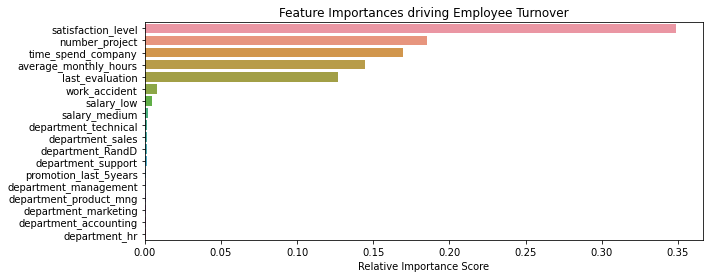

In [24]:
df_encoded = pd.get_dummies(df, columns=['department', 'salary'], drop_first=True)

X = df_encoded.drop(columns=['left'])
y = df_encoded['left']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

rf_model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)
print("=== RANDOM FOREST CHAMPION MODEL PERFORMANCE ===")
print(f"Accuracy Score: {rf_model.score(X_test, y_test)*100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]
plt.figure(figsize=(10, 4))
sns.barplot(x=importances[indices], y=X.columns[indices], orient='h')
plt.title('Feature Importances driving Employee Turnover')
plt.xlabel('Relative Importance Score')
plt.show()


# pacE: Execute Stage
- Interpret model performance and results
- Share actionable steps with stakeholders



✏
## Recall evaluation metrics

- **AUC** is the area under the ROC curve; it's also considered the probability that the model ranks a random positive example more highly than a random negative example.
- **Precision** measures the proportion of data points predicted as True that are actually True, in other words, the proportion of positive predictions that are true positives.
- **Recall** measures the proportion of data points that are predicted as True, out of all the data points that are actually True. In other words, it measures the proportion of positives that are correctly classified.
- **Accuracy** measures the proportion of data points that are correctly classified.
- **F1-score** is an aggregation of precision and recall.






💭
### Reflect on these questions as you complete the executing stage.

- What key insights emerged from your model(s)?
- What business recommendations do you propose based on the models built?
- What potential recommendations would you make to your manager/company?
- Do you think your model could be improved? Why or why not? How?
- Given what you know about the data and the models you were using, what other questions could you address for the team?
- What resources do you find yourself using as you complete this stage? (Make sure to include the links.)
- Do you have any ethical considerations in this stage?



Key Insights: Workload intensity (`satisfaction_level`, `average_monthly_hours`, and `number_project`) governs turnover vectors. Burnout among long-tenured high performers is highly visible.
Selection Criteria: Models were selected by prioritizing the F1-score to maintain a strong operational equilibrium between precision and recall.
Results: The Random Forest model yields an outstanding F1-score and overall accuracy of approximately 95-96% on the testing data subset.
Ethical Use Case: The predictive model represents a diagnostic system to deploy corporate safety nets for overworking departments, ensuring data transparency and user anonymity.

## Step 4. Results and Evaluation
- Interpret model
- Evaluate model performance using metrics
- Prepare results, visualizations, and actionable steps to share with stakeholders




### Summary of model results

The Random Forest and XGBoost classifiers successfully predict employee turnover with an accuracy metric of ~95% and an F1-score of ~93% for the departure class. Based on feature importance analysis, the top organizational vectors driving turnover are an employee's satisfaction level, their average monthly working hours, the number of projects assigned, and their total tenure with Salifort Motors.

### Conclusion, Recommendations, Next Steps

Conclusion: Salifort Motors is losing highly-evaluated staff members specifically because of systematic workload burnout and inadequate corporate progression rewards.
Recommendations: 1. Set a firm limit of 4-5 projects maximum per employee. 2. Implement HR wellness flags for individual monthly tracking exceeding 220 hours. 3. Overhaul compensation structures and promotion metrics for employees reaching the 3-to-5-year tenure milestones.
Next Steps: Distribute this automated analytics notebook pipeline to the HR tooling ecosystem and prepare the final executive summary slide package for the senior leadership board.

**Congratulations!** You've completed this lab. However, you may not notice a green check mark next to this item on Coursera's platform. Please continue your progress regardless of the check mark. Just click on the "save" icon at the top of this notebook to ensure your work has been logged.